In [1]:
from MultiOutputTuner import MultiOutputTuner, score
from dataLoader import *
from sklearn.model_selection import train_test_split
import json
import pandas as pd
from sklearn.preprocessing import StandardScaler
import shap
import torch

scaler = StandardScaler()

y = gt_train_df[column_names].values
y = scaler.fit_transform(y)
y_binned = np.digitize(y, bins=np.linspace(y.min(), y.max() + 1, 5))
y = torch.tensor(y, dtype=torch.float32)

In [2]:
def resize_tensor(x,size = (7,7)):
    x = x.unsqueeze(0)
    x = torch.nn.functional.interpolate(x, size=size, mode='bilinear', align_corners=False)
    return x.squeeze(0)

files_train = sorted(HSI_SATELLITE_DIR.glob("*.npz"))
train_data = []
for file in enumerate(files_train):
    file_name = file[1]
    with np.load(file_name) as npz:
        arr = np.ma.MaskedArray(**npz)
        data = arr.data
        data = np.append(data, [arr.mask[0]], axis=0)
        x = torch.tensor(data, dtype=torch.float32)
        x = resize_tensor(x)
        train_data.append(x)
        
max_width = max(data.shape[1] for data in train_data)
max_height = max(data.shape[2] for data in train_data)
min_width = min(data.shape[1] for data in train_data)
min_height = min(data.shape[2] for data in train_data)
max_size = max_width if max_width > max_height else max_height

In [3]:
from torch.utils.data import DataLoader
from neural_networks.Convolutional import CNN2D
from sklearn.model_selection import train_test_split

train_dataset = list(zip(train_data, y))
train, test = train_test_split(train_dataset, train_size=0.8)

# MSI batch size: 64
# MSI neurons: 256
# HSI batch size: 128
# HSI neurons: 128
train_loader = DataLoader(train, batch_size=128, shuffle=True)
test_loader = DataLoader(test, batch_size=len(test), shuffle=False)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = CNN2D(neurons=256, channels=231).to(device)
criterion = torch.nn.CrossEntropyLoss()
optimiser = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = torch.nn.MSELoss()

best_val_loss = float('inf')
best_val_loss_before = best_val_loss

print(column_names)

/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory
/opt/amdgpu/share/libdrm/amdgpu.ids: No such file or directory


['Fe', 'Zn', 'B', 'Cu', 'S', 'Mn']


# Getting statistics about y set

97.3 481.7 216.3089552238806
179.2 204.05 237.225


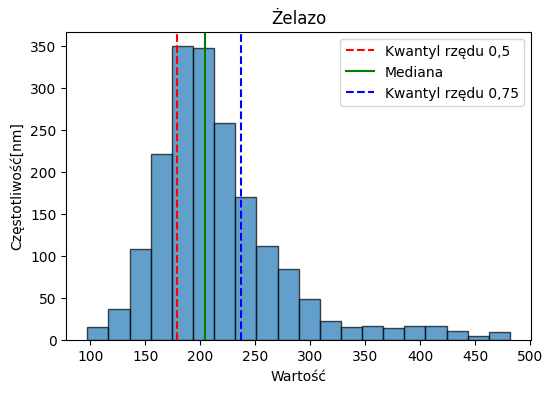

1.5 14.4 4.849147121535181
3.5 4.5 6.0


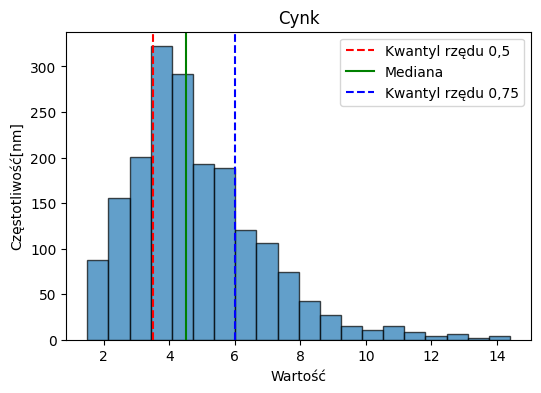

0.3 1.9 0.8538379530916844
0.7000000000000001 0.8 1.0


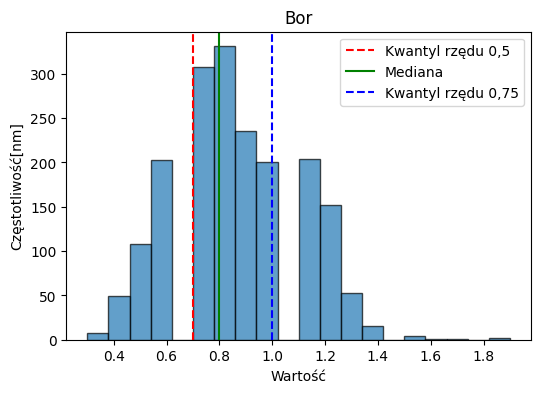

1.6 4.3 2.587100213219616
2.3 2.5 2.8


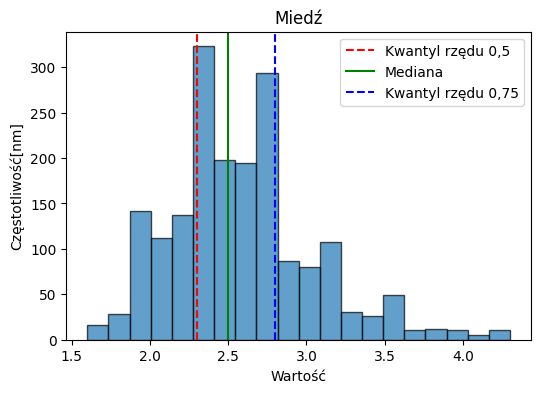

6.7133779365 96.8092647002 26.473430577582516
17.1005702002 24.871994424649998 32.1882949813


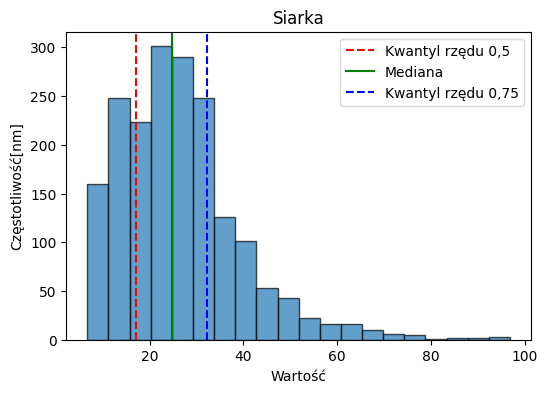

21.3 167.6 89.39456289978678
74.0 87.4 102.9


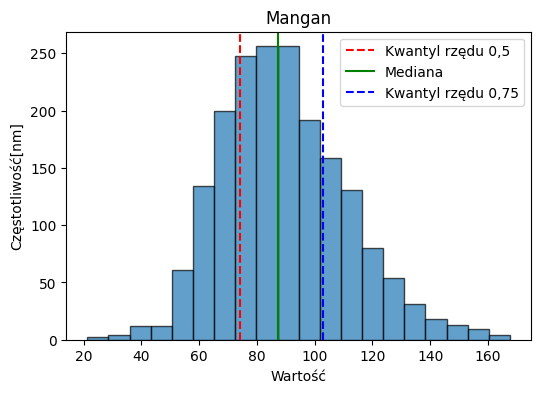

In [4]:
import matplotlib.pyplot as plt

df_subset = gt_train_df[column_names]
y_untransformed = df_subset.values

full_names = {
    "Fe":"Żelazo", 
    "Zn":"Cynk", 
    "B":"Bor", 
    "Cu":"Miedź", 
    "S":"Siarka", 
    "Mn":"Mangan"
}
for col in column_names:
    plt.figure(figsize=(6, 4))
    
    # Plot the histogram
    plt.hist(df_subset[col], bins=20, edgecolor='black', alpha=0.7)
    
    # Optional: Add lines showing where the quantiles fall
    plt.axvline(df_subset[col].quantile(0.25), color='red', linestyle='--', label='Kwantyl rzędu 0,5')
    plt.axvline(df_subset[col].median(), color='green', linestyle='-', label='Mediana')
    plt.axvline(df_subset[col].quantile(0.75), color='blue', linestyle='--', label='Kwantyl rzędu 0,75')

    print(df_subset[col].min(), df_subset[col].max(), df_subset[col].mean())
    print(df_subset[col].quantile(0.25), df_subset[col].median(), df_subset[col].quantile(0.75))
    
    plt.title(full_names[col])
    plt.xlabel('Wartość')
    plt.ylabel('Częstotliwość[nm]')
    plt.legend()
    plt.show()


In [5]:
from neural_networks.Convolutional import CNN2D
from interpret.blackbox import ShapKernel, LimeTabular
import numpy as np
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN2D(neurons=256, channels=231).to(device)
model.load_state_dict(torch.load("models/nn/CNN2D_HSI.pt"))
model.eval()

def predict_fn(X):
    X_tensor = torch.tensor(X, dtype=torch.float32)
    with torch.no_grad():
        outputs = model(X_tensor)

    return outputs.numpy()

with open("wavelengths.json", "r") as f:
    wavelengths = json.load(f)
    feature_names = list(wavelengths["hsi_satellite_wavelengths"].values())

background_tensor = train_data[1].unsqueeze(0).to(device)

explainer = shap.DeepExplainer(model, background_tensor)

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_wavelength_shap(target_idx, sample_idx=0):
    """
    Plots the top 20 SHAP values for a specific target column and sample.
    
    Parameters:
    -----------
    target_idx : int
        The index of the target output column you want to explain (e.g., 0 to 5)
    sample_idx : int, optional
        The index of the test sample to explain. Defaults to 0.
    """
    # 1. Extract the specific target and sample array safely
    if isinstance(shap_values, list):
        # shap_values is a list of length 6 (one per output column)
        sample_shap = shap_values[target_idx][sample_idx]
    else:
        # Handling if returned as an array with shape (num_targets, samples, channels, H, W)
        sample_shap = shap_values[target_idx][sample_idx]

    # 2. Bring the original input data sample back to CPU numpy
    sample_data = test_tensor[sample_idx].cpu().numpy()

    # 3. Collapse the 7x7 spatial layout into 1D channel averages
    sample_shap_per_channel = sample_shap.mean(axis=(1, 2)).flatten()

    # 4. Build a DataFrame for sorting the top 20 wavelengths
    df_shap = pd.DataFrame({
        'Wavelength': feature_names[:len(sample_shap_per_channel)],
        'SHAP Value': sample_shap_per_channel
    })

    # Filter out the highest absolute impact features
    df_shap['Abs Impact'] = df_shap['SHAP Value'].abs()
    top_features = df_shap.sort_values(by='Abs Impact', ascending=False).head(20)
    top_features = top_features.sort_values(by='SHAP Value', ascending=True) # Visual ordering

    # 5. Generate the Plot
    plt.figure(figsize=(11, 7))

    # Red color for positive impact, blue for negative impact
    colors = ['#ff0051' if val >= 0 else '#008bfb' for val in top_features['SHAP Value']]

    plt.barh(top_features['Wavelength'], top_features['SHAP Value'], color=colors, edgecolor='none')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

    # dynamically pull target name if you have a list like column_names, otherwise fallback to index
    try:
        target_name = column_names[target_idx]
    except NameError:
        target_name = f"Column Index {target_idx}"

    plt.title(f"Top 20 Wavelengths affecting: {target_name} (Sample {sample_idx})", fontsize=13, pad=15)
    plt.xlabel("SHAP Value (Impact on Target Output)")
    plt.ylabel("Satellite Wavelengths")
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

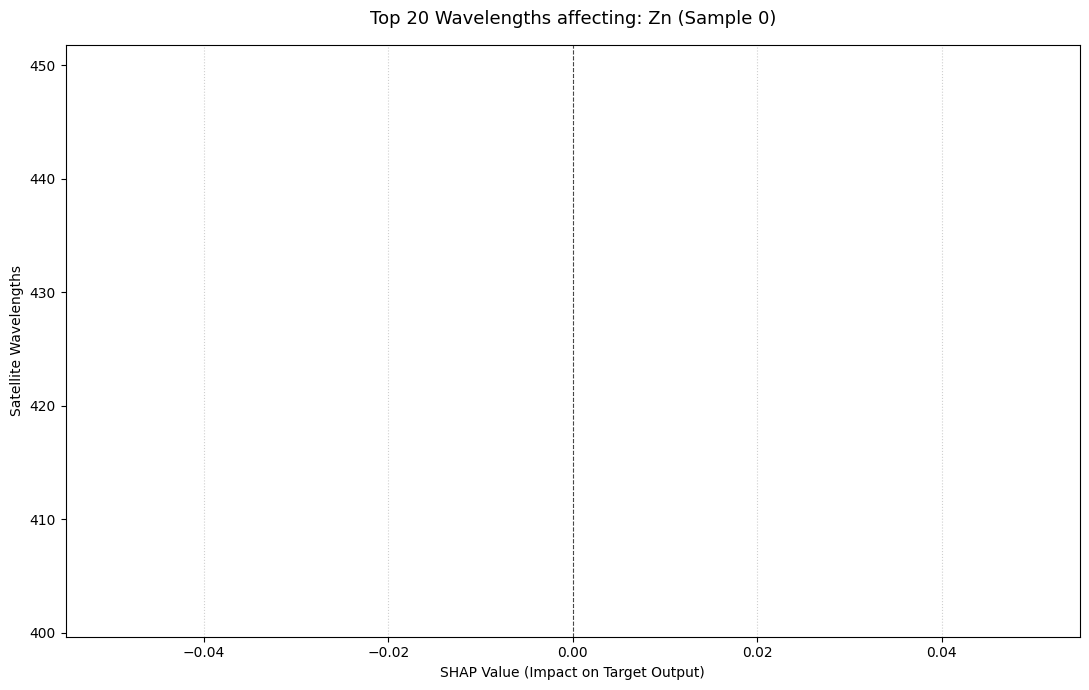

In [7]:
import shap
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

test_tensor = torch.stack(train_data[:3]).to(device)
shap_values = explainer.shap_values(test_tensor)

def plot_wavelength_shap(target_idx, sample_idx=0):
    """
    Plots the top 20 SHAP values for a specific target column and sample.
    """
    if isinstance(shap_values, list):
        sample_shap = shap_values[target_idx][sample_idx]
    else:
        sample_shap = shap_values[target_idx][sample_idx]

    sample_data = test_tensor[sample_idx].cpu().numpy()

    sample_shap_per_channel = sample_shap.mean(axis=(1, 2)).flatten()

    df_shap = pd.DataFrame({
        'Wavelength': feature_names[:len(sample_shap_per_channel)],
        'SHAP Value': sample_shap_per_channel
    })

    df_shap['Abs Impact'] = df_shap['SHAP Value'].abs()
    top_features = df_shap.sort_values(by='Abs Impact', ascending=False).head(20)
    top_features = top_features.sort_values(by='SHAP Value', ascending=True)

    plt.figure(figsize=(11, 7))

    colors = ['#ff0051' if val >= 0 else '#008bfb' for val in top_features['SHAP Value']]

    plt.barh(top_features['Wavelength'], top_features['SHAP Value'], color=colors, edgecolor='none')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

    try:
        target_name = column_names[target_idx]
    except NameError:
        target_name = f"Column Index {target_idx}"

    plt.title(f"Top 20 Wavelengths affecting: {target_name} (Sample {sample_idx})", fontsize=13, pad=15)
    plt.xlabel("SHAP Value (Impact on Target Output)")
    plt.ylabel("Satellite Wavelengths")
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_wavelength_shap(target_idx=1, sample_idx=0)

# LIME algorithm

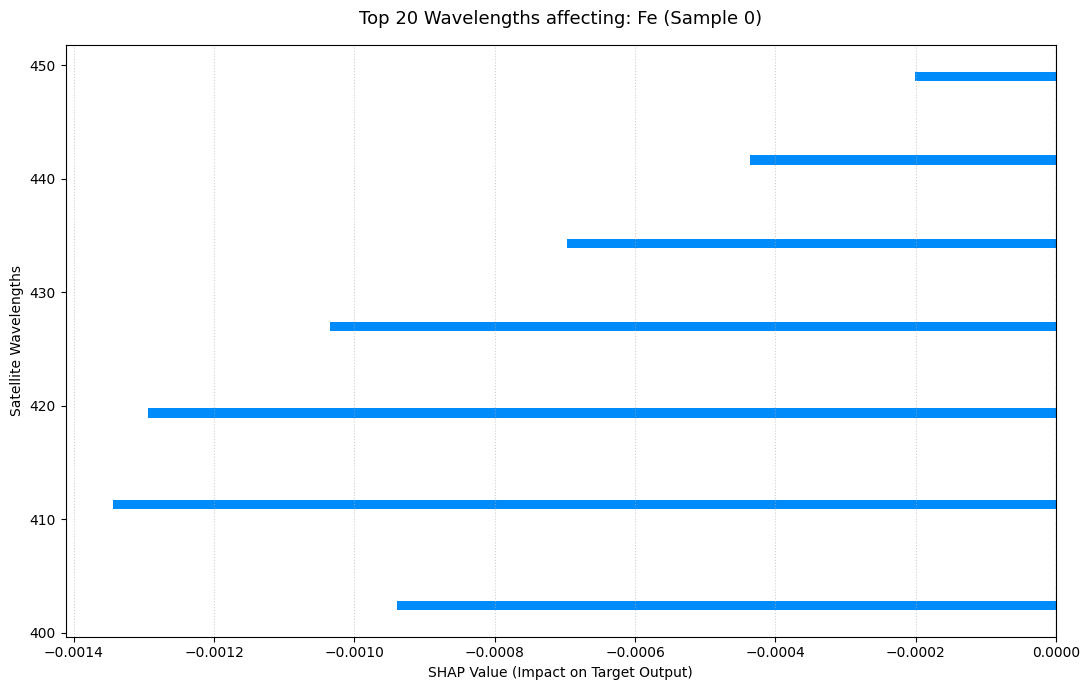

In [8]:
def plot_wavelength_lime(target_idx, sample_idx=0):
    """
    Computes LIME explanations for a specific target column and plots 
    the aggregated wavelength importances.
    """
    
    def lime_predict_fn(X_flat):
        X_cnn = X_flat.reshape(-1, 231, 7, 7)
        X_torch = torch.tensor(X_cnn, dtype=torch.float32).to(device)
        with torch.no_grad():
            outputs = model(X_torch)
        return outputs[:, target_idx].cpu().numpy()

    # FIX: Pass 'model' as the first argument, and explicitly name predict_fn
    lime_explainer = LimeTabular(
        model=model, 
        data=background_tabular, 
        predict_fn=lime_predict_fn, 
        feature_names=flat_feature_names
    )

    # Compute explanations local to our specific test sample
    lime_local_explanation = lime_explainer.explain_local(test_sample_flat, np.array([0]))

    # FIX: InterpretML handles local explanations as a dictionary of classes/outputs.
    # Because lime_predict_fn returns a single column, we grab the 0-th index dictionary key.
    perf_dict = lime_local_explanation.data(0)
    
    # Extract structural scores. In InterpretML, 'scores' matches the flat_feature_names order.
    flat_scores = perf_dict['scores']
    
    # Reshape scores back to (231, 49) to group by wavelength channel
    reshaped_scores = np.array(flat_scores).reshape(231, 49)
    
    # Average the local importance across the 7x7 spatial pixels
    lime_wavelength_scores = reshaped_scores.mean(axis=1)

    # Build DataFrame for visualization sorting
    df_lime = pd.DataFrame({
        'Wavelength': feature_names[:len(lime_wavelength_scores)],
        'LIME Weight': lime_wavelength_scores
    })

    df_lime['Abs Impact'] = df_lime['LIME Weight'].abs()
    top_features = df_lime.sort_values(by='Abs Impact', ascending=False).head(20)
    top_features = top_features.sort_values(by='LIME Weight', ascending=True)

    # Generate the Chart
    plt.figure(figsize=(11, 7))
    colors = ['#ff0051' if val >= 0 else '#008bfb' for val in top_features['LIME Weight']]

    plt.barh(top_features['Wavelength'], top_features['LIME Weight'], color=colors, edgecolor='none')
    plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8, alpha=0.7)

    try:
        target_name = column_names[target_idx]
    except NameError:
        target_name = f"Column Index {target_idx}"

    plt.title(f"Top 20 LIME Wavelength Weights affecting: {target_name} (Sample {sample_idx})", fontsize=13, pad=15)
    plt.xlabel("LIME Local Weight (Feature Contribution)")
    plt.ylabel("Satellite Wavelengths")
    plt.grid(axis='x', linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.show()

plot_wavelength_shap(target_idx=0, sample_idx=0)

# Visuallise LIME superpixels

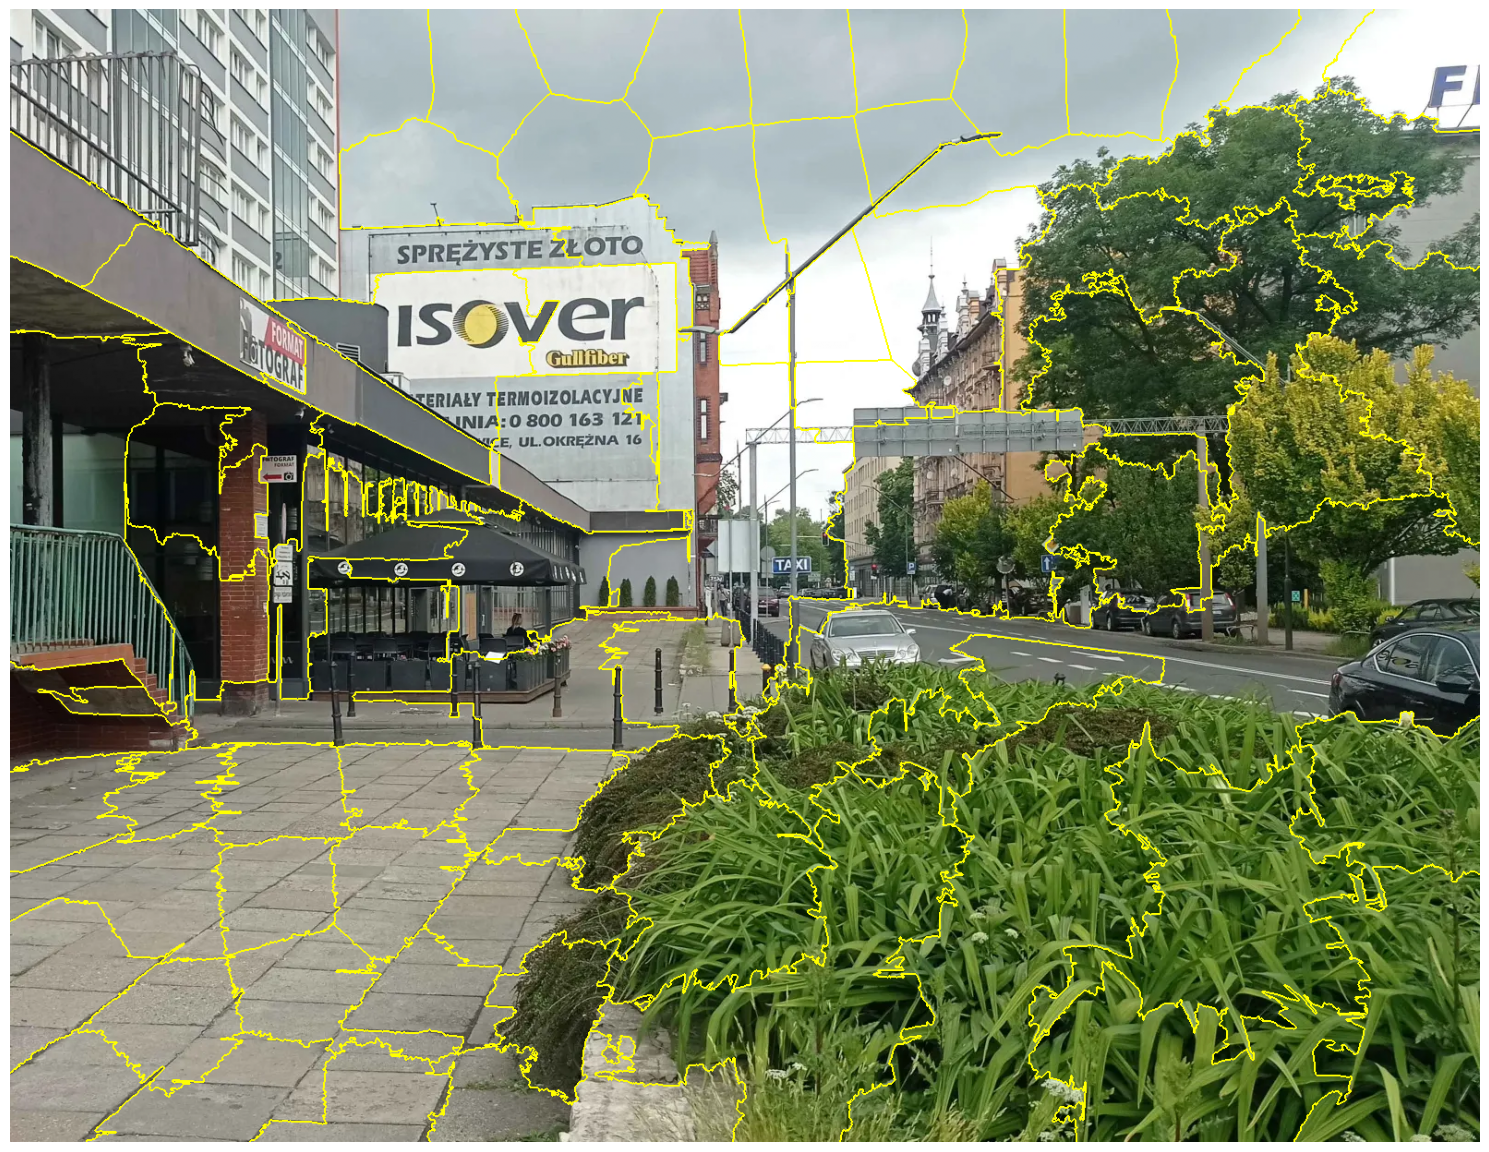

In [9]:
from PIL import Image
from skimage.segmentation import slic, mark_boundaries
import matplotlib.pyplot as plt

img = Image.open("image.png").convert("RGB")
img_np = np.array(img)

segments = slic(
    img_np,
    n_segments=150,
    compactness=10,
)

segmented_img = mark_boundaries(img_np, segments)

fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Plot the original image on the left (index 0)
axes[0].imshow(img_np)
axes[0].set_title("Original Image", fontsize=14)
axes[0].axis("off")

# Plot the segmented image on the right (index 1)
axes[1].imshow(segmented_img)
axes[1].set_title("SLIC Superpixels (n_segments=50)", fontsize=14)
axes[1].axis("off")

# 3. Render the comparison
plt.tight_layout()
plt.show()

# Prepare the best model to submission

In [10]:
from BaselineRegressor import BaselineRegressor
baseline_reg = BaselineRegressor()
baseline_reg = baseline_reg.fit(X_train, y_train)
baseline_predictions = baseline_reg.predict(X_test)

baseline_predictions_test = baseline_reg.predict(X_test_all)
submission = pd.DataFrame(data=baseline_predictions_test, columns=column_names)
submission.to_csv("submission.csv", index_label="sample_index")

NameError: name 'X_train' is not defined

In [ ]:
kNeighbors = MultiOutputTuner.load("models/gradientBoosting")
predictions = kNeighbors.predict(X_test_all)
submissions = pd.DataFrame(data=predictions, columns = column_names)
submission.to_csv("gradientBoosting.csv", index_label="sample_index")